# Download NASDAQ 100 price history (Yahoo Finance)

Pulls **daily OHLCV candles** for the NASDAQ 100 index (`^NDX`) from Yahoo
Finance, then writes them to a timestamped CSV under `data/`.

**Standalone** -- unlike `01_download_prices.ipynb` (IG), this notebook does
**not** read `.env` and needs no IG credentials or API key. Its parameters
(`TICKER` / `PERIOD` / `INTERVAL`) are set directly below, in the notebook.

Download logic lives in `igmarket/yahoo_finance.py`, not in this notebook --
`download_history()` (wraps `yfinance`), `csv_path_for()`, `save_csv()`.

## Flow

| # | section | what happens |
| --- | --- | --- |
| 1 | **Parameters** | set `TICKER`, `PERIOD`, `INTERVAL` |
| 2 | **Download** | `yahoo_finance.download_history()` pulls OHLCV via `yfinance` |
| 3 | **Save** | write `data/yahoo_<ticker-slug>_<interval>_<timestamp>.csv` |
| 4 | **Preview** | `tail(10)` / `describe()` + a close-price chart |

## Note on the CSV shape

Yahoo Finance has no bid/ask -- this CSV is a single `Open`/`High`/`Low`/
`Close`/`Volume` series, unlike the IG pipeline's bid/ask/mid columns
(`igmarket/constants/csv_headers.py`). It is **not** compatible with
`02_import_csv_to_db.ipynb` and isn't meant to feed `data/ig_market_data.db`.

**Prerequisite:** the `igmarket` package installed -- `uv sync --extra dev`
from the repo root. That brings in `yfinance` (download) and `pandas` /
`matplotlib` (preview/chart; section 4 degrades gracefully if they're
missing).

## 1. Parameters

No `.env` involved -- edit these directly and re-run.

- **`TICKER`** -- Yahoo Finance ticker. Default `^NDX` (NASDAQ 100 index).
- **`PERIOD`** -- how much history to pull, a `yfinance` period string
  (`"1mo"`, `"6mo"`, `"1y"`, `"5y"`, `"max"`, ...).
- **`INTERVAL`** -- candle size, a `yfinance` interval string (`"1d"`, `"1h"`,
  `"15m"`, ...). Intraday intervals only cover recent history -- Yahoo limits
  how far back sub-daily data goes.

In [1]:
TICKER = "^NDX"    # Yahoo Finance ticker for the NASDAQ 100 index
PERIOD = "ytd"      # how much history to pull (yfinance period string)
                    # valid values: "1d", "5d", "1mo", "3mo", "6mo", "1y", "2y", "5y", "10y", "ytd", "max"
INTERVAL = "1d"     # candle size (yfinance interval string)

import sys
print(sys.executable)

print(f"TICKER={TICKER!r}  PERIOD={PERIOD!r}  INTERVAL={INTERVAL!r}")

C:\repos\github.com\jupyter-notebooks\.venv\Scripts\python.exe
TICKER='^NDX'  PERIOD='ytd'  INTERVAL='1d'


## 2. Download

`yahoo_finance.download_history()` (`igmarket/yahoo_finance.py`) wraps
`yfinance.Ticker(TICKER).history(period=PERIOD, interval=INTERVAL)`, dropping
the `Dividends`/`Stock Splits` columns (an index has neither) and raising if
Yahoo returns no rows.

In [2]:
from igmarket.yahoo_finance import download_history

df = download_history(TICKER, period=PERIOD, interval=INTERVAL)

print(f"{len(df)} {INTERVAL} candles for {TICKER}")
print(f"  range: {df.index[0]}  ->  {df.index[-1]}")
df.tail(5)

176 1d candles for ^NDX
  range: 2026-01-02 00:00:00-05:00  ->  2026-09-15 00:00:00-04:00


,Open,High,Low,Close,Volume
Date,,,,,
2026-09-09 00:00:00-04:00,29431.939453,29563.599609,29334.400391,29421.550781,7379700000
2026-09-10 00:00:00-04:00,29097.339844,29250.410156,29038.220703,29103.509766,7174170000
2026-09-11 00:00:00-04:00,29331.480469,29473.119141,29313.509766,29368.439453,6587900000
2026-09-14 00:00:00-04:00,28890.929688,29285.500000,28867.669922,29127.160156,7179780000
2026-09-15 00:00:00-04:00,29100.160156,29142.800781,28899.429688,28937.839844,7934200000


## 3. Save to CSV

Always written (no `SAVE_CSV` toggle here) to a fresh, timestamped path under
`data/`: `csv_path_for()` builds `data/yahoo_<ticker-slug>_<interval>_<timestamp>.csv`
(`^NDX` -> `ndx`), and `save_csv()` writes `df` there, indexed by date.

In [3]:
from igmarket.yahoo_finance import csv_path_for, save_csv

CSV_PATH = csv_path_for(TICKER, INTERVAL)
save_csv(df, CSV_PATH)

print(f"wrote {CSV_PATH.resolve()}  ({len(df)} rows)")

wrote C:\repos\github.com\jupyter-notebooks\data\yahoo_ndx_1d_20260916192524.csv  (176 rows)


## 4. Preview + close chart

Needs `pandas` (already used above) and `matplotlib`
(`%pip install matplotlib`). A tail-10 table + `describe()`, then a close
line chart with a shaded high/low band.

In [4]:
if df.empty:
    print(f"Download returned 0 {INTERVAL} candles for {TICKER} - nothing to preview.")
else:
    display(df.tail(10))
    display(df.describe())

,Open,High,Low,Close,Volume
Date,,,,,
2026-09-01 00:00:00-04:00,29056.580078,29267.419922,28953.259766,29077.220703,6750660000
2026-09-02 00:00:00-04:00,29016.000000,29165.619141,28971.900391,29143.330078,7442550000
2026-09-03 00:00:00-04:00,29234.419922,29538.759766,29160.960938,29482.320312,7600140000
2026-09-04 00:00:00-04:00,29539.570312,29655.220703,29440.150391,29544.150391,6529110000
2026-09-08 00:00:00-04:00,29645.179688,29655.730469,29400.699219,29507.699219,7714560000
2026-09-09 00:00:00-04:00,29431.939453,29563.599609,29334.400391,29421.550781,7379700000
2026-09-10 00:00:00-04:00,29097.339844,29250.410156,29038.220703,29103.509766,7174170000
2026-09-11 00:00:00-04:00,29331.480469,29473.119141,29313.509766,29368.439453,6587900000
2026-09-14 00:00:00-04:00,28890.929688,29285.500000,28867.669922,29127.160156,7179780000


,Open,High,Low,Close,Volume
count,176.000000,176.000000,176.000000,176.000000,1.760000e+02
mean,27399.098489,27587.599099,27194.340854,27408.101829,8.990207e+09
std,2204.027341,2207.888404,2187.396025,2200.238754,1.672498e+09
min,23208.000000,23356.750000,22841.419922,22953.380859,6.529110e+09
25%,25221.550781,25342.362793,24990.557617,25182.854980,7.920808e+09
50%,28064.535156,28314.309570,27815.384766,28072.780273,8.681555e+09
75%,29374.657715,29645.722168,29147.639648,29416.082520,9.708605e+09
max,30730.109375,30762.199219,30441.800781,30660.599609,1.828615e+10


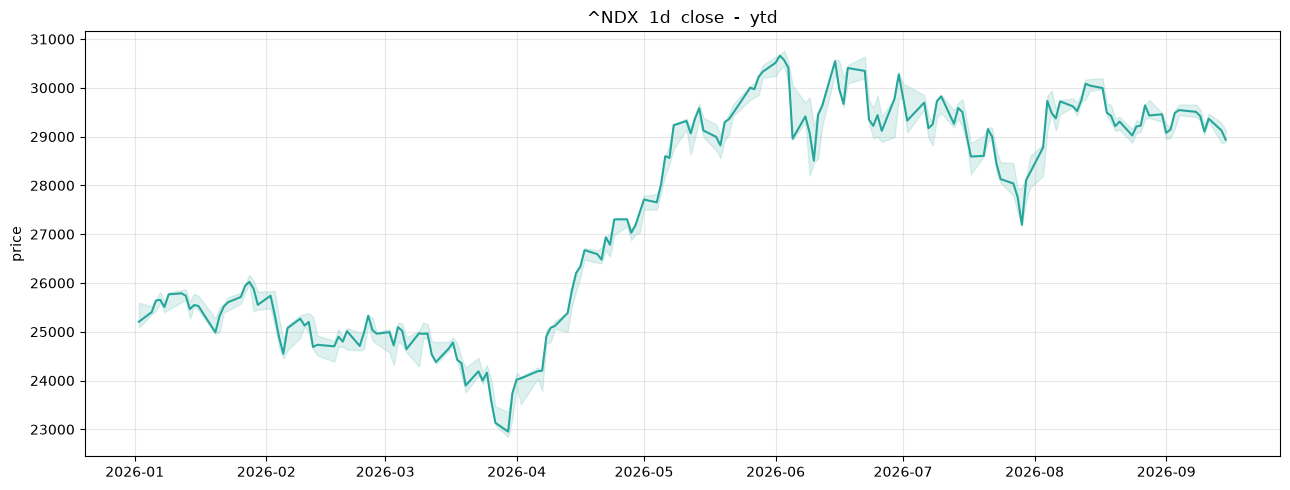

In [5]:
if df.empty:
    print("Nothing to plot.")
else:
    try:
        import matplotlib.pyplot as plt
    except ModuleNotFoundError:
        print("matplotlib not installed - run:  %pip install matplotlib")
    else:
        fig, ax = plt.subplots(figsize=(13, 5))
        ax.plot(df.index, df["Close"], color="#26a69a")
        ax.fill_between(df.index, df["Low"], df["High"], color="#26a69a", alpha=0.15)
        ax.set_title(f"{TICKER}  {INTERVAL}  close  -  {PERIOD}")
        ax.set_ylabel("price")
        ax.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()